<a href="https://colab.research.google.com/github/AIML-Dept/Prajwal_T_Raj_1GA23AI034/blob/main/Quantum_Tutorial_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q qiskit qiskit-aer pylatexenc matplotlib pandas scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.7 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from scipy.stats import chisquare

simulator = AerSimulator()

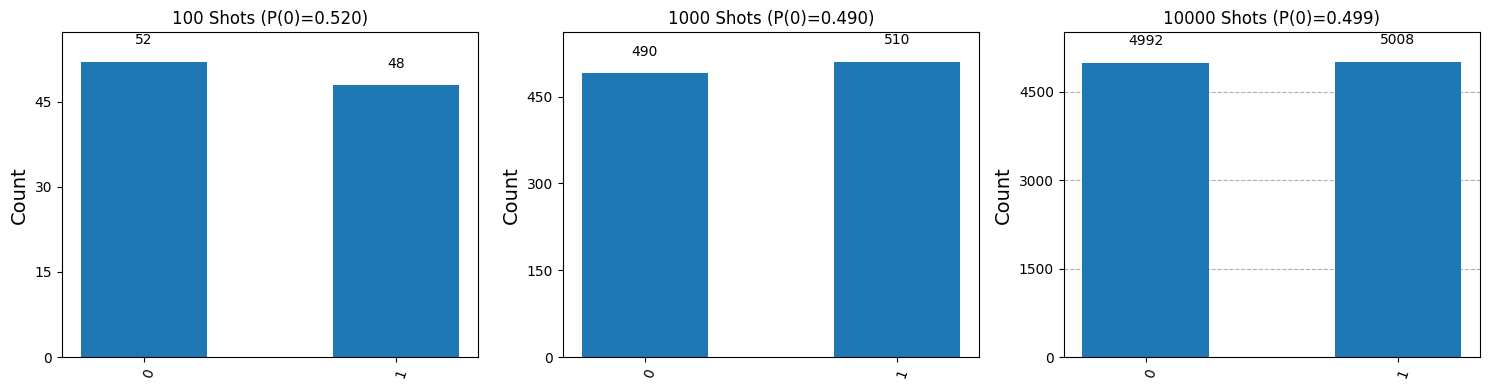

,Shots,Count |0>,Count |1>,P(|0>),P(|1>),Error (|P-0.5|)
0,100,52,48,0.5200,0.4800,0.0200
1,1000,490,510,0.4900,0.5100,0.0100
2,10000,4992,5008,0.4992,0.5008,0.0008


In [3]:
# Exercise 1: Probability Convergence with Shot Count (Easy)
# Circuit: Single qubit superposition
qc_easy = QuantumCircuit(1, 1)
qc_easy.h(0)
qc_easy.measure(0, 0)

shot_counts = [100, 1000, 10000]
results_data = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, shots in enumerate(shot_counts):
    counts = simulator.run(transpile(qc_easy, simulator), shots=shots).result().get_counts()
    p0 = counts.get("0", 0) / shots
    p1 = counts.get("1", 0) / shots
    results_data.append(
        {
            "Shots": shots,
            "Count |0>": counts.get("0", 0),
            "Count |1>": counts.get("1", 0),
            "P(|0>)": round(p0, 4),
            "P(|1>)": round(p1, 4),
            "Error (|P-0.5|)": round(abs(p0 - 0.5), 4),
        }
    )

    plot_histogram(counts, ax=axes[i])
    axes[i].set_title(f"{shots} Shots (P(0)={p0:.3f})")

plt.tight_layout()
plt.show()

# Display convergence summary table
df_convergence = pd.DataFrame(results_data)
display(df_convergence)

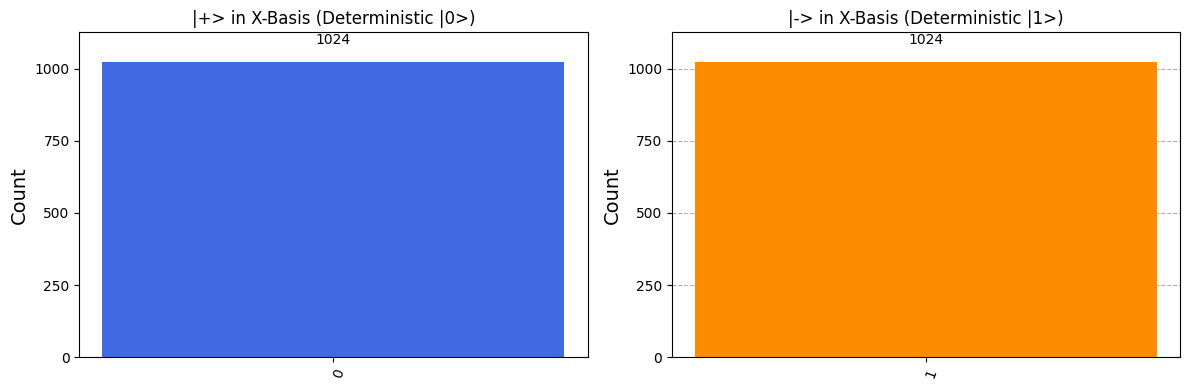

In [4]:
# Exercise 2: Measurement in the X-Basis (Medium)
# Circuit 1: Prepare |+> and measure in X-basis
qc_plus = QuantumCircuit(1, 1)
qc_plus.h(0)  # Prepare |+>
qc_plus.h(0)  # Basis rotation to X-basis
qc_plus.measure(0, 0)

# Circuit 2: Prepare |-> and measure in X-basis
qc_minus = QuantumCircuit(1, 1)
qc_minus.x(0)
qc_minus.h(0)  # Prepare |->
qc_minus.h(0)  # Basis rotation to X-basis
qc_minus.measure(0, 0)

# Simulations
counts_plus = simulator.run(transpile(qc_plus, simulator), shots=1024).result().get_counts()
counts_minus = simulator.run(transpile(qc_minus, simulator), shots=1024).result().get_counts()

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_histogram(counts_plus, ax=axes[0], color="royalblue")
axes[0].set_title("|+> in X-Basis (Deterministic |0>)")
plot_histogram(counts_minus, ax=axes[1], color="darkorange")
axes[1].set_title("|-> in X-Basis (Deterministic |1>)")
plt.tight_layout()
plt.show()

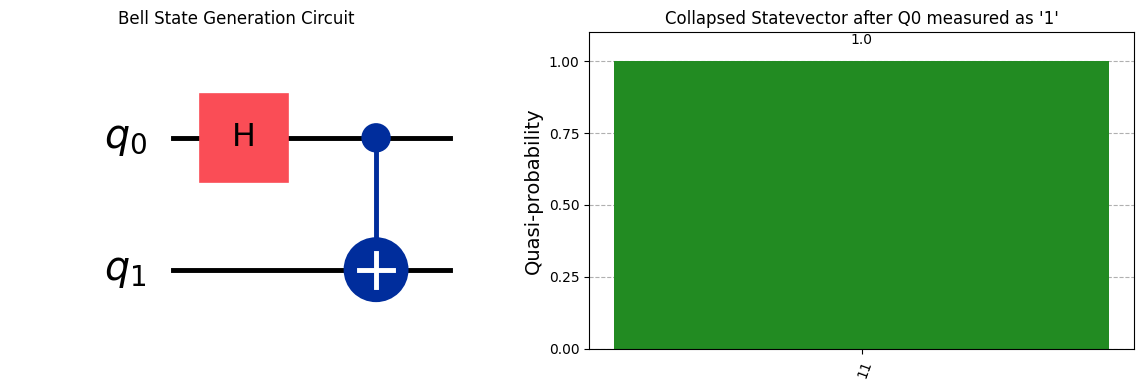

Outcome of Qubit 0 measurement : |1>
Collapsed State of Qubit 1      : Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


In [5]:
#Exercise 3: Partial Measurement on a Bell Pair (Hard)
# Prepare Bell state
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

# Get initial statevector
sv_initial = Statevector.from_instruction(qc_bell)

# Perform projective measurement on qubit 0 only
measured_bit, collapsed_sv = sv_initial.measure([0])

# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
qc_bell.draw("mpl", ax=ax[0])
ax[0].set_title("Bell State Generation Circuit")

probs = collapsed_sv.probabilities_dict()
plot_histogram(probs, ax=ax[1], color="forestgreen")
ax[1].set_title(f"Collapsed Statevector after Q0 measured as '{measured_bit}'")
plt.tight_layout()
plt.show()

print(f"Outcome of Qubit 0 measurement : |{measured_bit}>")
print(f"Collapsed State of Qubit 1      : {collapsed_sv}")

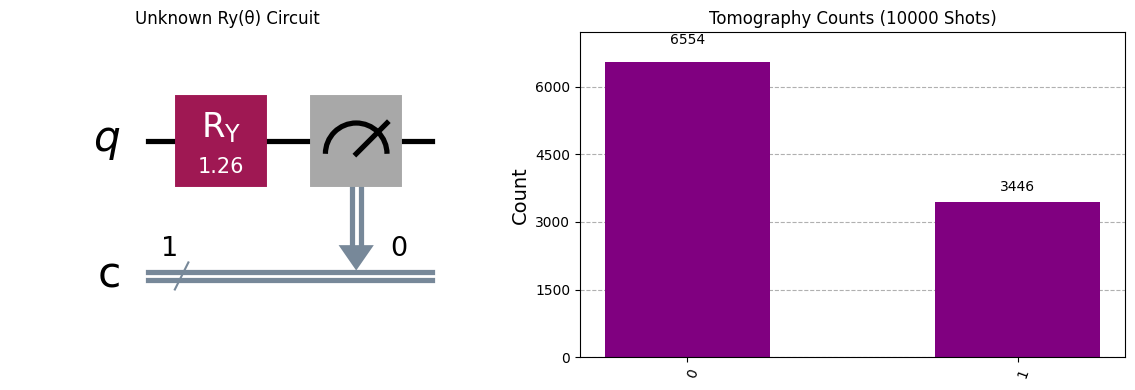

True Theta Value      : 1.2566 rad
Estimated Theta Value : 1.2548 rad
Estimation Error      : 0.0018 rad


In [6]:
#Exercise 4: Unknown Rotation Estimation via Tomography (Real-World)
# Define hidden true angle
theta_true = 1.2566  # e.g., ~0.4*pi

qc_tomo = QuantumCircuit(1, 1)
qc_tomo.ry(theta_true, 0)
qc_tomo.measure(0, 0)

shots = 10000
counts_tomo = simulator.run(transpile(qc_tomo, simulator), shots=shots).result().get_counts()

# Reconstruct angle from statistics
p1_measured = counts_tomo.get("1", 0) / shots
theta_estimated = 2 * np.arcsin(np.sqrt(p1_measured))

# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
qc_tomo.draw("mpl", ax=ax[0])
ax[0].set_title("Unknown Ry(θ) Circuit")

plot_histogram(counts_tomo, ax=ax[1], color="purple")
ax[1].set_title(f"Tomography Counts ({shots} Shots)")
plt.tight_layout()
plt.show()

print(f"True Theta Value      : {theta_true:.4f} rad")
print(f"Estimated Theta Value : {theta_estimated:.4f} rad")
print(f"Estimation Error      : {abs(theta_true - theta_estimated):.4f} rad")

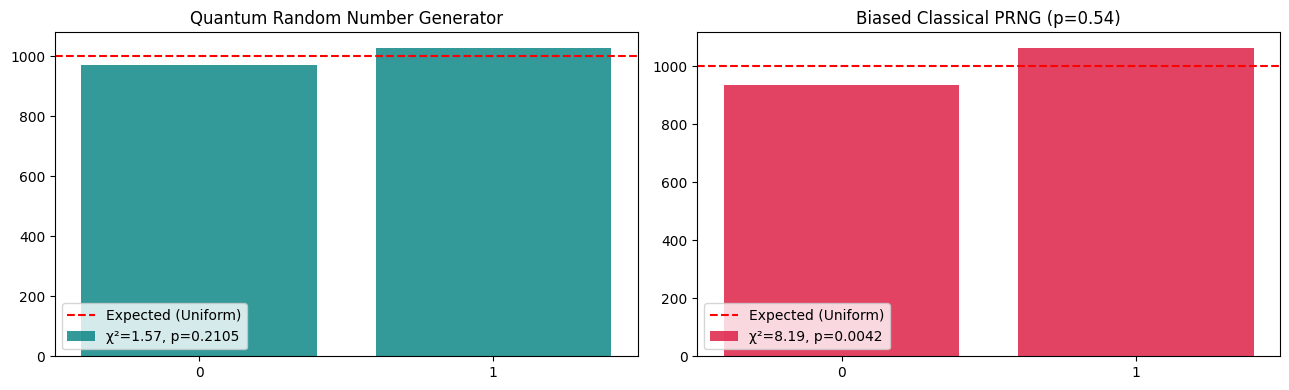

QRNG Result : p-value = 0.2105 -> Passes Fair Test (Cannot Reject Null)
PRNG Result : p-value = 0.0042 -> Detected Bias (Reject Null Hypothesis)


In [7]:
# Exercise 5: Quantum vs. Biased Classical Generator Hypothesis Testing (Challenge)
# 1. Quantum Random Bit Generator (QRNG)
qc_qrng = QuantumCircuit(1, 1)
qc_qrng.h(0)
qc_qrng.measure(0, 0)
shots_n = 2000

counts_qrng = simulator.run(transpile(qc_qrng, simulator), shots=shots_n).result().get_counts()
obs_qrng = [counts_qrng.get("0", 0), counts_qrng.get("1", 0)]

# 2. Biased Classical Pseudo-Random Generator (PRNG)
biased_samples = np.random.choice([0, 1], p=[0.46, 0.54], size=shots_n)
obs_prng = [np.sum(biased_samples == 0), np.sum(biased_samples == 1)]

# Hypothesis Testing against expected uniform distribution [1000, 1000]
expected = [shots_n / 2, shots_n / 2]
chi_q, p_val_q = chisquare(obs_qrng, f_exp=expected)
chi_c, p_val_c = chisquare(obs_prng, f_exp=expected)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(
    ["0", "1"],
    obs_qrng,
    color="teal",
    alpha=0.8,
    label=f"χ²={chi_q:.2f}, p={p_val_q:.4f}",
)
axes[0].axhline(shots_n / 2, color="red", linestyle="--", label="Expected (Uniform)")
axes[0].set_title("Quantum Random Number Generator")
axes[0].legend()

axes[1].bar(
    ["0", "1"],
    obs_prng,
    color="crimson",
    alpha=0.8,
    label=f"χ²={chi_c:.2f}, p={p_val_c:.4f}",
)
axes[1].axhline(shots_n / 2, color="red", linestyle="--", label="Expected (Uniform)")
axes[1].set_title("Biased Classical PRNG (p=0.54)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    f"QRNG Result : p-value = {p_val_q:.4f} -> {'Passes Fair Test (Cannot Reject Null)' if p_val_q > 0.05 else 'Failed'}"
)
print(
    f"PRNG Result : p-value = {p_val_c:.4f} -> {'Detected Bias (Reject Null Hypothesis)' if p_val_c <= 0.05 else 'Undetected'}"
)